# **Conditional Graph**

In [1]:
from typing import TypedDict, Literal;

class State(TypedDict):
    number: int;
    category: str;
    result: str;

def classify_node(state: State) -> dict:

    """Decide which category the number belongs to"""

    n = state["number"];

    if n < 0:
        cat = "negative";
    elif n == 0:
        cat = "zero";
    elif n % 2 == 0:
        cat = "even";
    else:
        cat = "odd";

    print(f"[classify] {n} → {cat}");

    return {"category": cat};

In [2]:
def negative_node(state: State) -> dict:

    return {"result": f"{state["number"]} is a negative number 🔴"};

def zero_node(state: State) -> dict:

    return {"result": f"{state["number"]} is exactly zero ⚪"};

def even_node(state: State) -> dict:

    return {"result": f"{state["number"]} is a positive even number 🟢"};

def odd_node(state: State) -> dict:

    return {"result": f"{state["number"]} is a positive odd number 🔵"};

def route_by_category(state: State) -> Literal["negative", "zero", "even", "odd"]: # Conditional Edge

    return state["category"];

In [3]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("classify", classify_node);

builder.add_node("negative", negative_node);

builder.add_node("zero", zero_node);

builder.add_node("even", even_node);

builder.add_node("odd", odd_node)

builder.add_edge(START, "classify");

builder.add_conditional_edges(
    "classify", 
    route_by_category,
    {
        "negative": "negative",
        "zero": "zero",
        "even": "even",
        "odd": "odd"
    }
);

for branch in ["negative", "zero", "even", "odd"]:

    builder.add_edge(branch, END); # All Branches Put In END

graph = builder.compile();

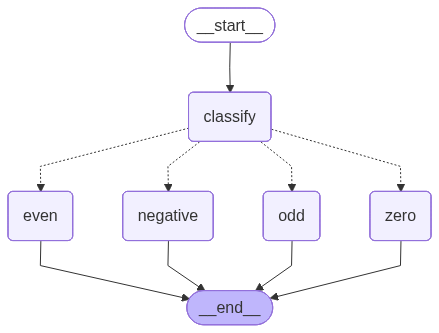

In [ ]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png())); # In Photo Dots Line Present Conditional

In [5]:
for num in [-7, 0, 4, 9, 100]:

    r = graph.invoke({
        "number": num, 
        "category": "", 
        "result": ""
    });

    print(f"{r["result"]} \n");

[classify] -7 → negative
-7 is a negative number 🔴 

[classify] 0 → zero
0 is exactly zero ⚪ 

[classify] 4 → even
4 is a positive even number 🟢 

[classify] 9 → odd
9 is a positive odd number 🔵 

[classify] 100 → even
100 is a positive even number 🟢 

